In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

gold_path = project_root / 'data' / 'gold' / 'marts'
gold_path

WindowsPath('e:/Data_Engineering_First_Year_Project/foreign_exchange_rates_pipeline/fx_pipeline/data/gold/marts')

In [2]:
daily_rates = pd.read_parquet(gold_path / 'gold_daily_currency_rates.parquet')
movement = pd.read_parquet(gold_path / 'gold_currency_movement.parquet')
weekly_summary = pd.read_parquet(gold_path / 'gold_weekly_currency_summary.parquet')
rankings = pd.read_parquet(gold_path / 'gold_strength_rankings.parquet')
conversion_reference = pd.read_parquet(gold_path / 'gold_conversion_reference.parquet')

In [3]:
weekly_summary.sort_values('weekly_pct_change', ascending=False).head()

,target_currency,weekly_avg,weekly_high,weekly_low,start_rate,end_rate,weekly_change,weekly_pct_change
5,JPY,159.176000,159.83000,158.85000,159.83000,159.13000,-0.7000,-0.437965
4,INR,93.184000,93.44000,92.82000,93.33000,92.82000,-0.5100,-0.546448
3,GBP,0.739468,0.74510,0.73699,0.74510,0.73890,-0.0062,-0.832103
2,EUR,0.849830,0.85587,0.84767,0.85587,0.84767,-0.0082,-0.958089
1,CAD,1.375700,1.38450,1.36720,1.38450,1.36720,-0.0173,-1.249549


In [4]:
movement[['rate_date', 'target_currency', 'exchange_rate', 'percentage_movement']].tail(10)

,rate_date,target_currency,exchange_rate,percentage_movement
110,2026-04-02,JPY,159.60,0.808489
111,2026-04-07,JPY,159.84,0.150376
112,2026-04-08,JPY,158.15,-1.057307
113,2026-04-09,JPY,158.92,0.486880
114,2026-04-10,JPY,159.19,0.169897
115,2026-04-13,JPY,159.83,0.402035
116,2026-04-14,JPY,158.85,-0.613151
117,2026-04-15,JPY,159.09,0.151086
118,2026-04-16,JPY,158.98,-0.069143
119,2026-04-17,JPY,159.13,0.094351


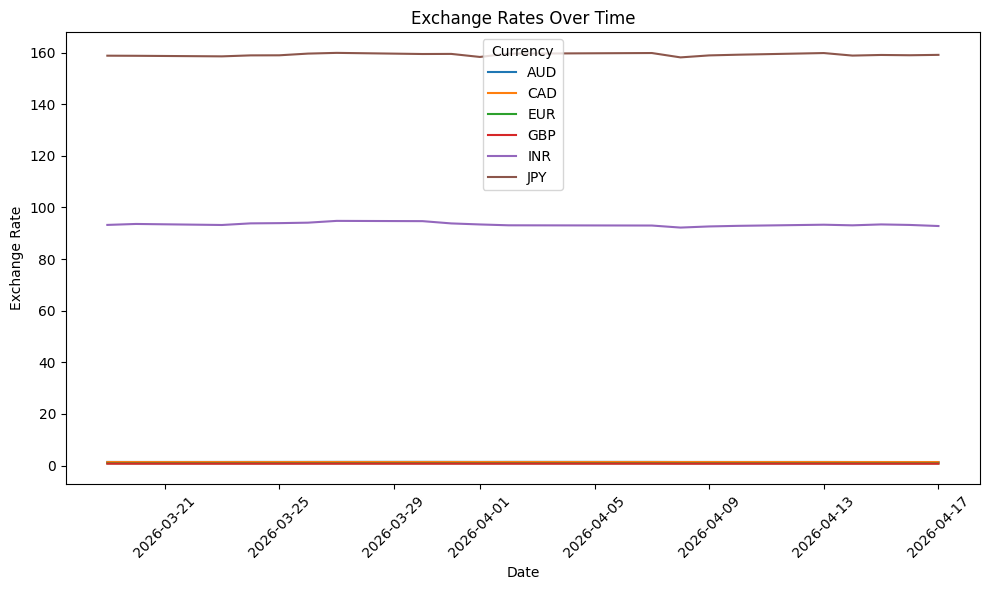

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for currency in daily_rates['target_currency'].unique():
    subset = daily_rates[daily_rates['target_currency'] == currency]
    ax.plot(subset['rate_date'], subset['exchange_rate'], label=currency)

ax.set_title('Exchange Rates Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Exchange Rate')
ax.legend(title='Currency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()